# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 60     |  |
| :-------------|:-------------|
| Wobbe van der Woude| 6581099|

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="IMG_3811.jpg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit 

def vlakkeplaat(e_0, e_r, A, d):
    C = e_0 * e_r * (A / d)
    return C

def cilinder(e_0, e_r, L, r_binnen, r_buiten):
    C = (2 * np.pi * e_0 * e_r * L) / (np.log(r_buiten/r_binnen))
    return  C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

e_0 = 8.854e-12 # F/m
e_r_lucht = 1.00056 

L1_plaat = 99.67 / 1000 # m
L2_plaat = 100.08 / 1000 # m
A_plaat = L1_plaat * L2_plaat

C_verwacht = vlakkeplaat(e_0, e_r_lucht, A_plaat, 0.001)


print(f"Verwachte capaciteit plaatcondensator groep 60 is {C_verwacht:.1e} F")

#de uitgewerkte formules zijn:

#V_out = C * 8 * np.pi * 4 * f * R
#C = (V_out / 2) / (8 * np.pi * 2 * f * R)

#daadwerkelijk gemeten is V  = 1.065 , daaruit krijg je 105 pF, wat groter is dan 50 pF, dit omdat de afstand iets kleiner was dan 1mm

Verwachte capaciteit plaatcondensator groep 60 is 8.8e-11 F


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](IMG_3807.jpg)
![scope meting 2](IMG_3810.jpg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 60| 88 pF | 0.88 V | 1.06 V | 105 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](IMG_3814.jpg)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die verschil tussen dielektrische waarde van glycerol en lucht meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](IMG_3815.jpg)

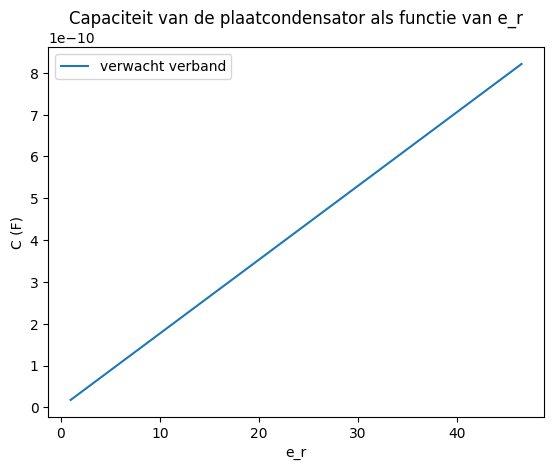

1.766368325088e-11


In [3]:
#de e_r wordt steeds groter naarmate er steeds meer glycerol tussen de platen komt te zitten
#e_r_glycerol = 46.5 bij kamer temperatuur 
#totdat dus 100% glycerol ertussen zit dan 46.5 helemaal, maar daartussen mengelmoes van lucht en glycerol
#verwacht dat gwn lineair is tussen 1 en 46.5, dus bij 50% glycerol zou e_r ongeveer 23 moeten zijn, en dat zou dan een capaciteit van ongeveer 2.1 nF moeten geven

#vaste dingen zijn: e_0, A_plaat, d_plaat
#d plaat is 1 mm
e_r_waardes = np.linspace(1, 46.5, 1000)
C_waardes = vlakkeplaat(e_0, e_r_waardes, A_plaat, 0.005)



plt.figure()
plt.plot(e_r_waardes, C_waardes, label="verwacht verband")
plt.title("Capaciteit van de plaatcondensator als functie van e_r")
plt.xlabel("e_r")
plt.ylabel("C (F)")
plt.legend()
plt.show()

print(vlakkeplaat(e_0, 1, A_plaat, 0.005))

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 1000 |4000 |
| gemiddelde capaciteit| 2000 |6000 |
| maximale capaciteit| 4000 |7000 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](IMG_3837.jpg)
![meting 2](IMG_3845.jpg)

## Opdracht 7: Plot de kalibratiegrafiek.

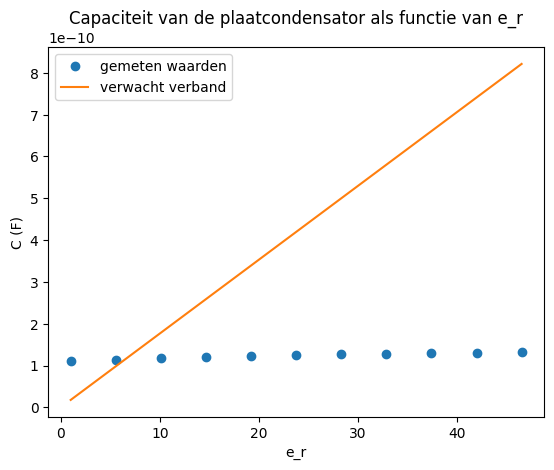

In [4]:
C_waardes_meting = np.array([110.8,114.0,117.0,120.0, 122.5,124.5,126.5,128.2,129.4,130.8,132.4]) * 1e-12
h = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

e_r_verhouding = 1 + (46.5 - 1) * (h / 1)

plt.figure()
plt.plot(e_r_verhouding, C_waardes_meting, "o", label="gemeten waarden")
plt.plot(e_r_waardes, C_waardes, label="verwacht verband")
plt.title("Capaciteit van de plaatcondensator als functie van e_r")
plt.xlabel("e_r")
plt.ylabel("C (F)")
plt.legend()
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* verbetering 1: grotere afstand, in plaats van 1mm 5mm (deze iteratie is al doorgevoerd)
* verbetering 2: grotere plaatoppervlak, waardoor nauwkeurigere stapjes ook gemeten zouden kunnen worden bijvoorbeeld, en miss platen van ander materiaal want dit werkt niet echt goed.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](IMG_3846.jpg)

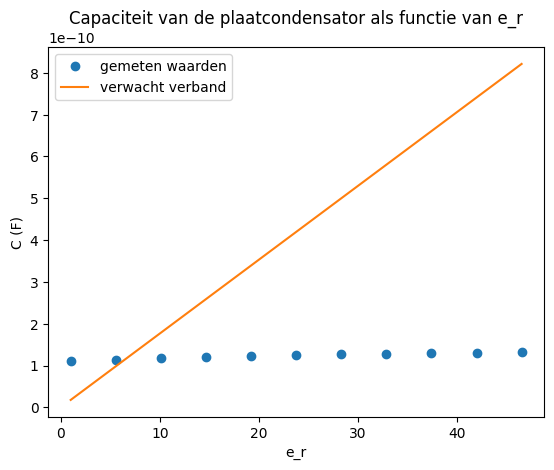

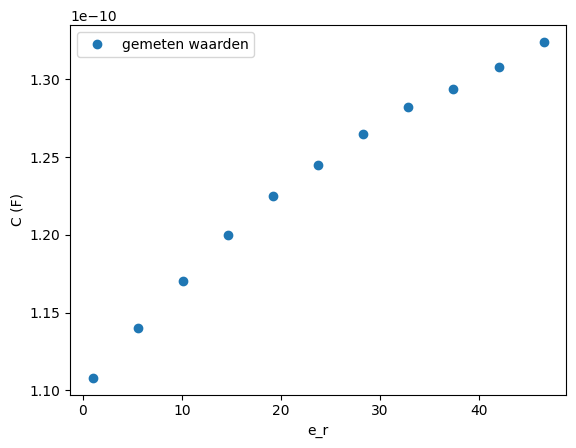

In [5]:
C_waardes_meting = np.array([110.8,114.0,117.0,120.0, 122.5,124.5,126.5,128.2,129.4,130.8,132.4]) * 1e-12
h = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

e_r_verhouding = 1 + (46.5 - 1) * (h / 1)

plt.figure()
plt.plot(e_r_verhouding, C_waardes_meting, "o", label="gemeten waarden")
plt.plot(e_r_waardes, C_waardes, label="verwacht verband")
plt.title("Capaciteit van de plaatcondensator als functie van e_r")
plt.xlabel("e_r")
plt.ylabel("C (F)")
plt.legend()
plt.show()

plt.figure()
plt.plot(e_r_verhouding, C_waardes_meting, "o", label="gemeten waarden")
plt.xlabel("e_r")
plt.ylabel("C (F)")
plt.legend()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

We zien dat de theoretische waarde helemaal niet overeenkomt met de gemeten waarde. De C waarde stijgt in de praktijk veel minder snel zo hoog dat de theorie voorspelt. We denken dat dit komt omdat er natuurlijk allemaal best wel grote onzekerheden op de condensator zitten zoals aan de randen waar ook een enorm veld en lading ontstaat en ook aan de achterkant met de paperclip aan de achterkant is dat niet helemaal zuiver. Ook de kabels enzo hebben een weerstand en lading. de condensator met 100% lucht is theoretisch wel veel lager dan in de praktijk. Dit waarschijnlijk door deze redenenen. Echter de losse grafiek van alleen de gemeten punten laat een aardig lineaire lijn zien. De metingen zijn erg constant met een kleine kromming in het midden, wat te verklaren valt door het capateitische effect wat tussen de platen gebeurt ten opzicht van de bak. Al deze externe factoren zorgen dat de theorie niet overeenkomt en dat valt hiermee te zien.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 1000 |4000 |
| gemiddelde capaciteit| 2000 |6000 |
| maximale capaciteit| 4000 |7000 |
 Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
gaat zijn.

e_0 = 8.854e-12 # F/m
e_r_lucht = 1.00056 

L1_plaat = 99.67 / 1000 # m
L2_plaat = 100.08 / 1000 # m
A_plaat = L1_plaat * L2_plaat

C_verwacht = vlakkeplaat(e_0, e_r_lucht, A_plaat, 0.001)


print(f"Verwachte capaciteit plaatcondensator groep 60 is {C_verwacht:.1e} F")

#de uitgewerkte formules zijn:

#V_out = C * 8 * np.pi * 4 * f * R
#C = (V_out / 2) / (8 * np.pi * 2 * f * R)

#daadwerkelijk gemeten is V  = 1.065 , daaruit krijg je 105 pF, wat groter is dan 50 pF, dit omdat de afstand iets kleiner was dan 1mm

<img src="IMG_3811.jpg" alt="schets student 1" width="400"/>
<img src="IMG_3807.jpg" alt="schets student 1" width="400"/>
<img src="IMG_3815.jpg" alt="schets student 1" width="400"/>
<img src="IMG_3814.jpg" alt="schets student 1" width="400"/>

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

<img src="IMG_3811.jpg" alt="schets student 1" width="400"/>
<img src="IMG_3840.jpg" alt="schets student 1" width="400"/>
<img src="IMG_3815.jpg" alt="schets student 1" width="400"/>
<img src="IMG_3846.jpg" alt="schets student 1" width="400"/>
<img src="IMG_3837.jpg" alt="schets student 1" width="400"/>

Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
gaat zijn.

e_0 = 8.854e-12 # F/m
e_r_lucht = 1.00056 

L1_plaat = 99.67 / 1000 # m
L2_plaat = 100.08 / 1000 # m
A_plaat = L1_plaat * L2_plaat

C_verwacht = vlakkeplaat(e_0, e_r_lucht, A_plaat, 0.001)


print(f"Verwachte capaciteit plaatcondensator groep 60 is {C_verwacht:.1e} F")

#de uitgewerkte formules zijn:

#V_out = C * 8 * np.pi * 4 * f * R
#C = (V_out / 2) / (8 * np.pi * 2 * f * R)

#daadwerkelijk gemeten is V  = 1.065 , daaruit krijg je 105 pF, wat groter is dan 50 pF, dit omdat de afstand iets kleiner was dan 1mm


def vlakkeplaat(e_0, e_r, A, d):
    C = e_0 * e_r * (A / d)
    return C

def cilinder(e_0, e_r, L, r_binnen, r_buiten):
    C = (2 * np.pi * e_0 * e_r * L) / (np.log(r_buiten/r_binnen))
    return  C

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.



C_waardes_meting = np.array([110.8,114.0,117.0,120.0, 122.5,124.5,126.5,128.2,129.4,130.8,132.4]) * 1e-12
h = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

e_r_verhouding = 1 + (46.5 - 1) * (h / 1)

plt.figure()
plt.plot(e_r_verhouding, C_waardes_meting, "o", label="gemeten waarden")
plt.plot(e_r_waardes, C_waardes, label="verwacht verband")
plt.title("Capaciteit van de plaatcondensator als functie van e_r")
plt.xlabel("e_r")
plt.ylabel("C (F)")
plt.legend()
plt.show()

plt.figure()
plt.plot(e_r_verhouding, C_waardes_meting, "o", label="gemeten waarden")
plt.xlabel("e_r")
plt.ylabel("C (F)")
plt.legend()
plt.show()

We zien dat de theoretische waarde helemaal niet overeenkomt met de gemeten waarde. De C waarde stijgt in de praktijk veel minder snel zo hoog dat de theorie voorspelt. We denken dat dit komt omdat er natuurlijk allemaal best wel grote onzekerheden op de condensator zitten zoals aan de randen waar ook een enorm veld en lading ontstaat en ook aan de achterkant met de paperclip aan de achterkant is dat niet helemaal zuiver. Ook de kabels enzo hebben een weerstand en lading. de condensator met 100% lucht is theoretisch wel veel lager dan in de praktijk. Dit waarschijnlijk door deze redenenen. Echter de losse grafiek van alleen de gemeten punten laat een aardig lineaire lijn zien. De metingen zijn erg constant met een kleine kromming in het midden, wat te verklaren valt door het capateitische effect wat tussen de platen gebeurt ten opzicht van de bak. Al deze externe factoren zorgen dat de theorie niet overeenkomt en dat valt hiermee te zien.